In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [10]:
data = sns.load_dataset('tips')

# Basic Info about the data

In [12]:
data.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [10]:
data.shape

(244, 7)

In [12]:
data.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


### The dataset contains 3 numeric and 3 category columns

## Statistical Summary

In [18]:
data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Checking for null values

In [21]:
data.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### The dataset does not contain null values in any of the columns.

## Checking for duplicates

In [14]:
data.duplicated().sum()

1

In [16]:
data[data.duplicated()]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


### Dataset contains one duplicated row.

## Dropping Duplicates

In [20]:
data.drop_duplicates(inplace=True)

In [22]:
data.duplicated().sum()

0

## Detecting Outliers

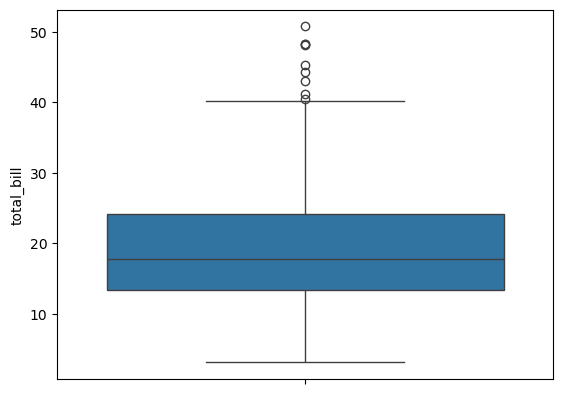

In [25]:
sns.boxplot(y='total_bill',data=data)
plt.show()

In [27]:
data.total_bill.describe()

count    243.000000
mean      19.813868
std        8.910071
min        3.070000
25%       13.380000
50%       17.810000
75%       24.175000
max       50.810000
Name: total_bill, dtype: float64

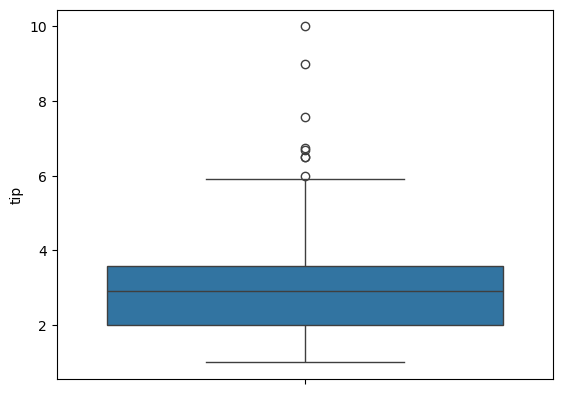

In [29]:
sns.boxplot(y='tip',data=data)
plt.show()

In [31]:
data.tip.describe()

count    243.000000
mean       3.002387
std        1.385002
min        1.000000
25%        2.000000
50%        2.920000
75%        3.575000
max       10.000000
Name: tip, dtype: float64

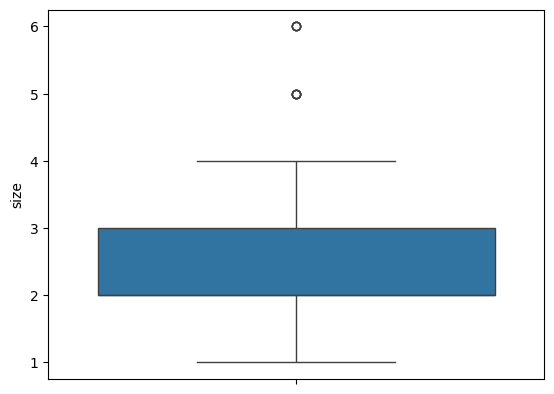

In [33]:
sns.boxplot(y='size',data=data)
plt.show()

In [35]:
data['size'].describe()

count    243.000000
mean       2.572016
std        0.952356
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: size, dtype: float64

### All of the numeric columns contain outliers.

## Removing Outliers using IQR Method

In [39]:
# User Defined function to remove outliers
def outlier(dt):
    Q1=dt.quantile(0.25)
    Q3=dt.quantile(0.75)

    IQR = Q3-Q1
    Upper_Bound = Q3 + 1.5*IQR
    Lower_Bound = Q1 - 1.5*IQR
    
    return dt.clip(Upper_Bound,Lower_Bound)

In [41]:
data['Total_Bill'] = outlier(data.total_bill)

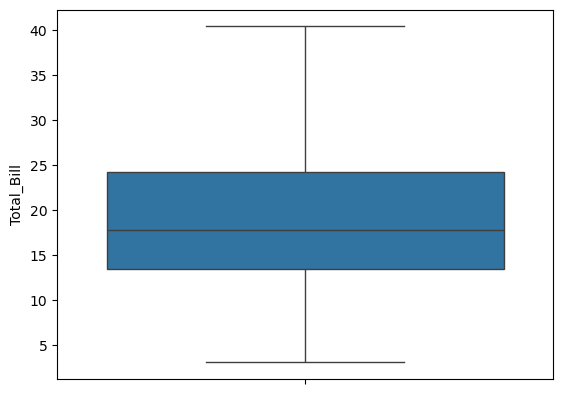

In [43]:
sns.boxplot(y='Total_Bill',data=data)
plt.show()

In [45]:
data['Tip']=outlier(data.tip)

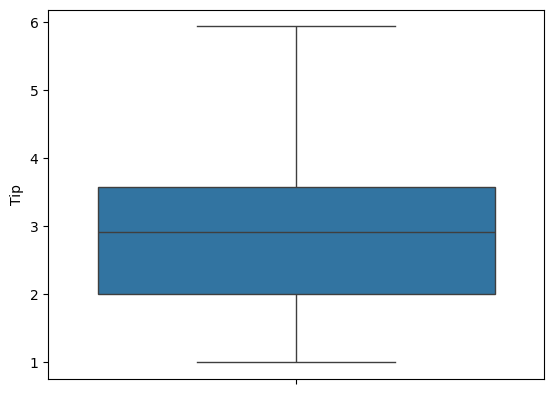

In [47]:
sns.boxplot(y='Tip',data=data)
plt.show()

In [49]:
data['Size'] = outlier(data['size'])

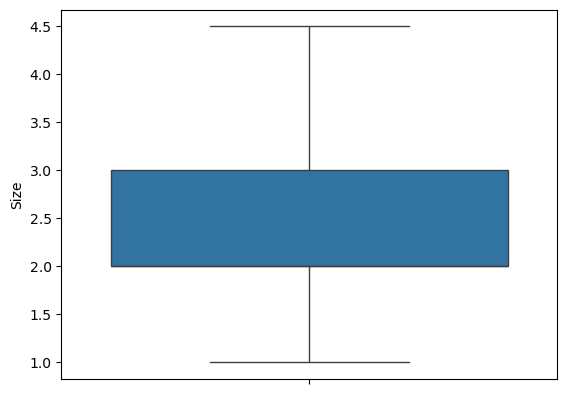

In [51]:
sns.boxplot(y='Size',data=data)
plt.show()

In [53]:
data.head(10)

,total_bill,tip,sex,smoker,day,time,size,Total_Bill,Tip,Size
0,16.99,1.01,Female,No,Sun,Dinner,2,16.99,1.01,2.0
1,10.34,1.66,Male,No,Sun,Dinner,3,10.34,1.66,3.0
2,21.01,3.50,Male,No,Sun,Dinner,3,21.01,3.50,3.0
3,23.68,3.31,Male,No,Sun,Dinner,2,23.68,3.31,2.0
4,24.59,3.61,Female,No,Sun,Dinner,4,24.59,3.61,4.0
5,25.29,4.71,Male,No,Sun,Dinner,4,25.29,4.71,4.0
6,8.77,2.00,Male,No,Sun,Dinner,2,8.77,2.00,2.0
7,26.88,3.12,Male,No,Sun,Dinner,4,26.88,3.12,4.0
8,15.04,1.96,Male,No,Sun,Dinner,2,15.04,1.96,2.0
9,14.78,3.23,Male,No,Sun,Dinner,2,14.78,3.23,2.0


# Analysis

## Average Bill Amount on the basis of Smoker type

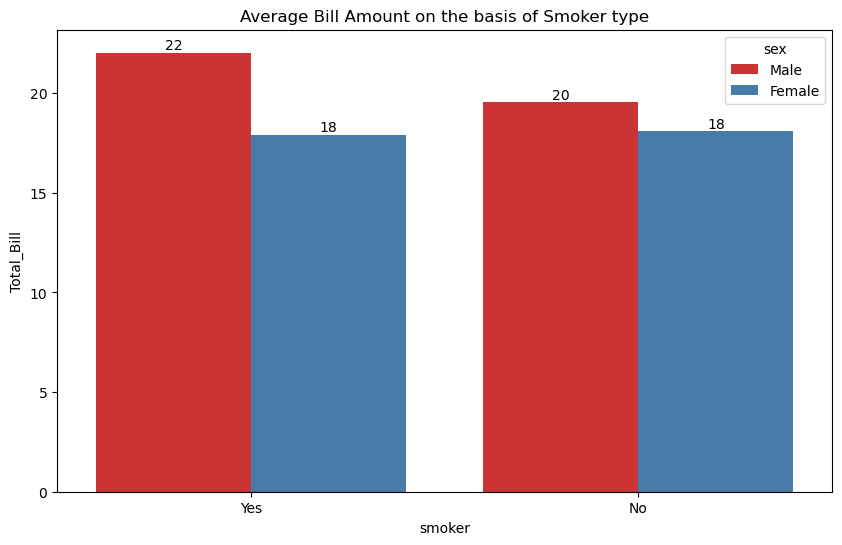

In [62]:
plt.figure(figsize = (10,6),dpi=100)
plt1 =sns.barplot(x='smoker',y='Total_Bill',data=data,errorbar=('ci',False),hue='sex',palette="Set1")
for i in plt1.containers:
    plt1.bar_label(i,fmt='%.f')
plt.title('Average Bill Amount on the basis of Smoker type')
plt.show()

## Count of Smokers and Non-Smokers

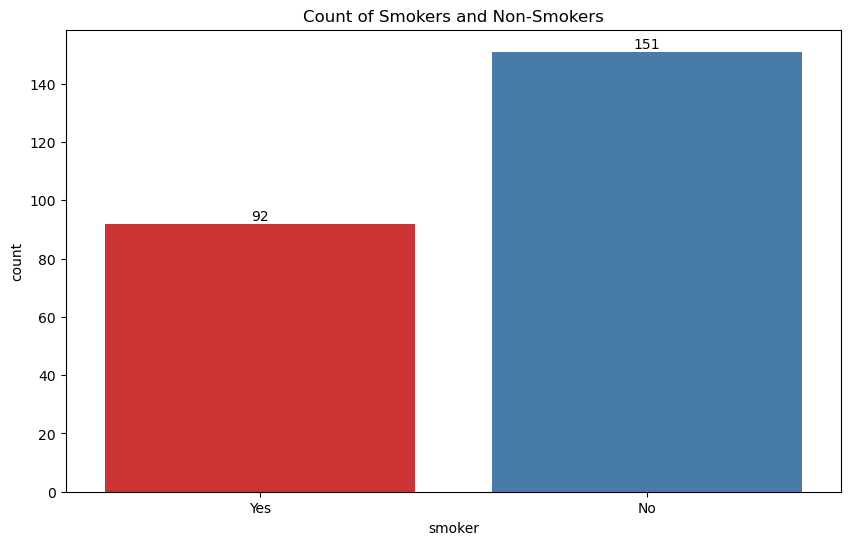

In [66]:
plt.figure(figsize=(10,6),dpi=100)
plt2=sns.countplot(x='smoker',data=data,hue='smoker',palette='Set1')

for i in plt2.containers:
    plt2.bar_label(i)
plt.title("Count of Smokers and Non-Smokers")
plt.show()     

## Distribution of Days

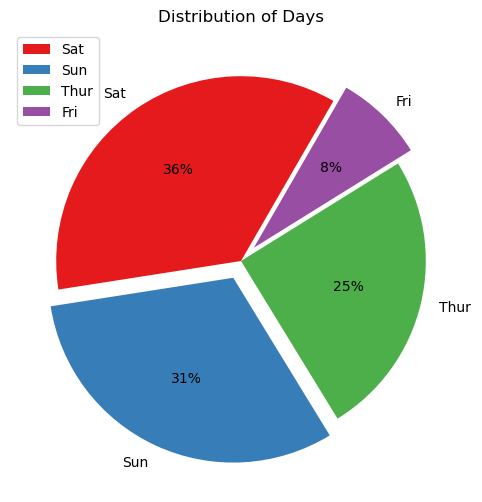

In [78]:
plt.figure(figsize=(10,6),dpi=100)
explode = [0,0.1,0,0.1]
colors = sns.color_palette("Set1")
plt.pie(data['day'].value_counts(),labels=data['day'].value_counts().index,autopct='%.f%%',startangle=60,explode=explode,colors=colors)
plt.title('Distribution of Days')
plt.legend()
plt.show()

## Maximum Tip on the basis of Gender and Smoker Type

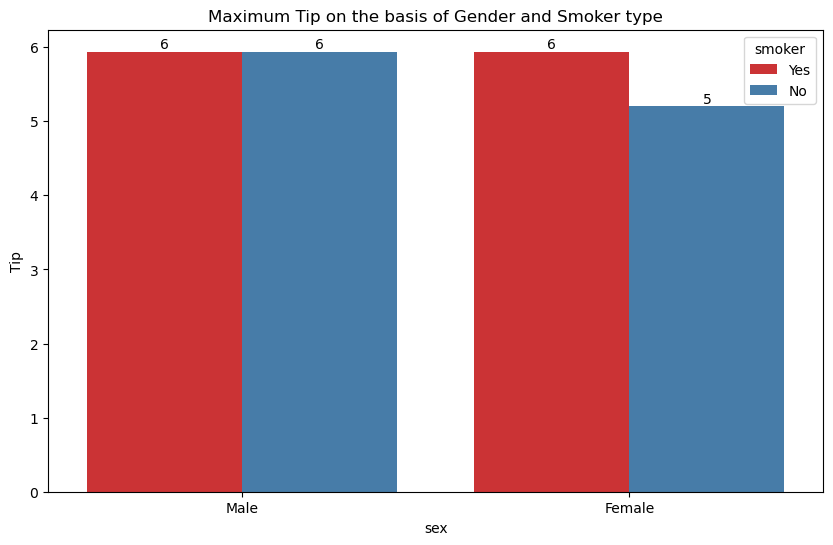

In [97]:
plt.figure(figsize = (10,6),dpi=100)
plt3 =sns.barplot(x='sex',y='Tip',data=data,errorbar=('ci',False),hue='smoker',palette="Set1",estimator=np.max)
for i in plt3.containers:
    plt3.bar_label(i,fmt='%.f')
plt.title('Maximum Tip on the basis of Gender and Smoker type')
plt.show()

## Relationship between Total_Bill and Tip on the basis of Day of the week

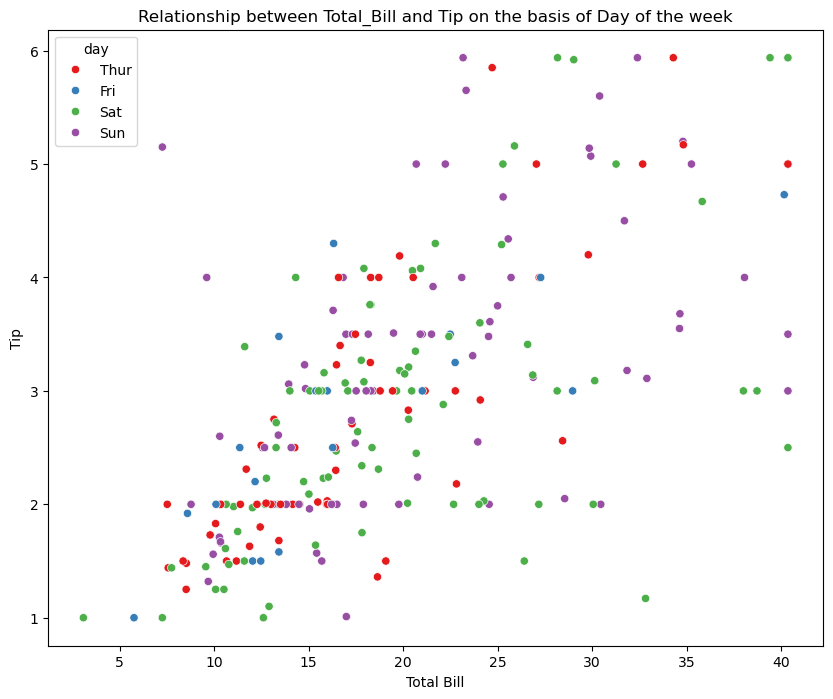

In [109]:
plt.figure(figsize=(10,8),dpi=100)
sns.scatterplot(x='Total_Bill',y='Tip',hue='day',data=data,palette='Set1')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Relationship between Total_Bill and Tip on the basis of Day of the week')
plt.show()

## Distribution of Time

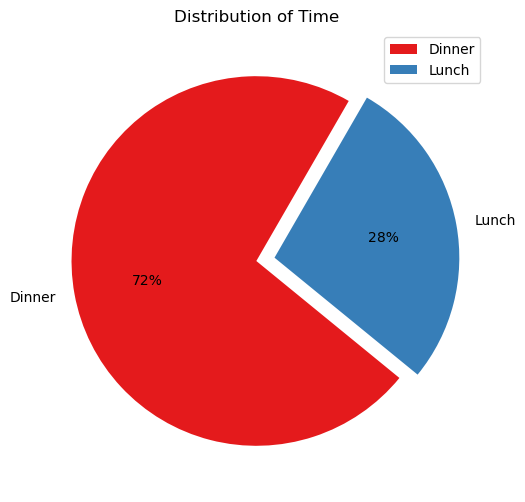

In [112]:
plt.figure(figsize=(10,6),dpi=100)
explode = [0,0.1,0,0.1]
colors = sns.color_palette("Set1")
explode = [0,0.1]
plt.pie(data['time'].value_counts(),labels=data['time'].value_counts().index,autopct='%.f%%',startangle=60,explode=explode,colors=colors)
plt.title('Distribution of Time')
plt.legend()
plt.show()

## Correlation Analysis

In [115]:
selected_columns = ['Total_Bill','Tip','Size']
numeric_data = data[selected_columns]

In [117]:
numeric_data.corr()

,Total_Bill,Tip,Size
Total_Bill,1.000000,0.653676,0.612747
Tip,0.653676,1.000000,0.501964
Size,0.612747,0.501964,1.000000


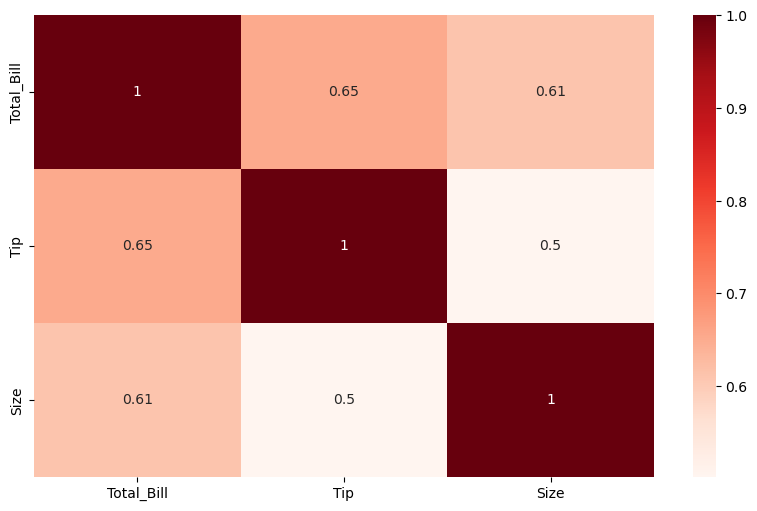

In [131]:
plt.figure(figsize=(10,6),dpi=100)
sns.heatmap(numeric_data.corr(),annot=True,cmap="Reds")
plt.show()